Saved: arrhenius_ni_bcc_fe.png

Quick reference table:
  Temp (C)    kBT (meV)     Ea/kBT    Rel. rate
------------------------------------------------
       300       49.39        18.6     5.126e+01
       350       53.70        17.1     2.285e+02
       400       58.01        15.9     8.159e+02
       450       62.31        14.8     2.443e+03
       480       64.90        14.2     4.398e+03
       500       66.62        13.8     6.347e+03
       550       70.93        13.0     1.468e+04
       600       75.24        12.2     3.086e+04


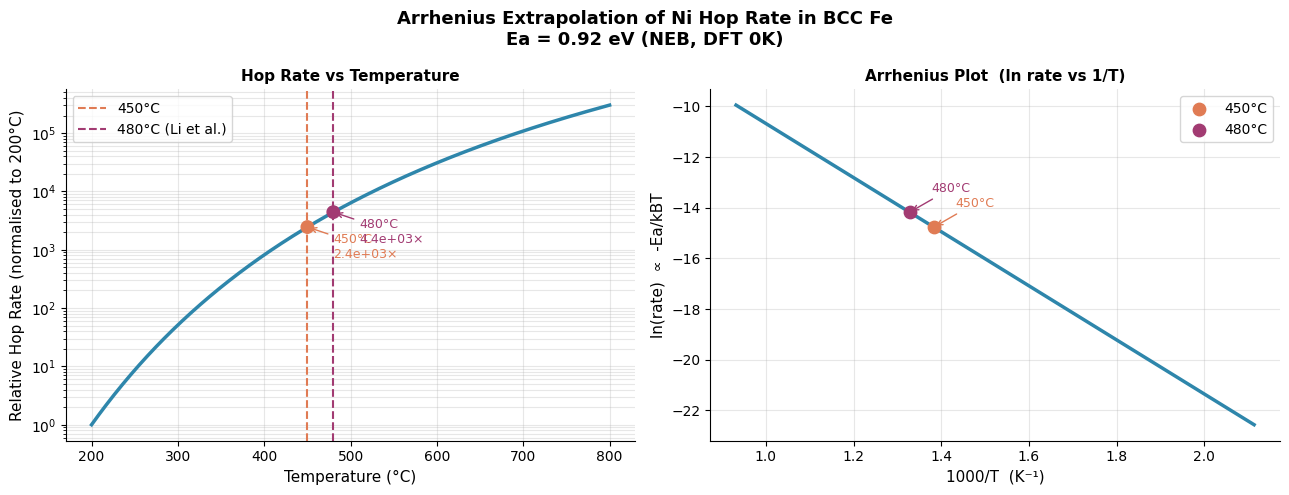

In [1]:
# python3 << 'EOF'
import math
import matplotlib.pyplot as plt
import numpy as np

Ea = 0.920  # eV
kB = 8.617e-5  # eV/K

temps_C = np.linspace(200, 800, 500)
temps_K = temps_C + 273.15
rates = np.exp(-Ea / (kB * temps_K))
rates_norm = rates / rates[0]  # normalise to rate at 200C

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Arrhenius Extrapolation of Ni Hop Rate in BCC Fe\nEa = 0.92 eV (NEB, DFT 0K)", 
             fontsize=13, fontweight='bold')

# ── Plot 1: Rate vs Temperature ───────────────────────────────────────────────
ax1.semilogy(temps_C, rates_norm, color='#2E86AB', linewidth=2.5)
ax1.axvline(450, color='#E07B54', linestyle='--', linewidth=1.5, label='450°C')
ax1.axvline(480, color='#A23B72', linestyle='--', linewidth=1.5, label='480°C (Li et al.)')
ax1.scatter([450, 480],
            [rates_norm[np.argmin(abs(temps_C-450))],
             rates_norm[np.argmin(abs(temps_C-480))]],
            color=['#E07B54','#A23B72'], s=80, zorder=5)
ax1.set_xlabel("Temperature (°C)", fontsize=11)
ax1.set_ylabel("Relative Hop Rate (normalised to 200°C)", fontsize=11)
ax1.set_title("Hop Rate vs Temperature", fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, which='both', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# annotate
for T, c in [(450,'#E07B54'), (480,'#A23B72')]:
    idx = np.argmin(abs(temps_C - T))
    ax1.annotate(f"{T}°C\n{rates_norm[idx]:.1e}×",
                 xy=(T, rates_norm[idx]),
                 xytext=(T+30, rates_norm[idx]*0.3),
                 fontsize=9, color=c,
                 arrowprops=dict(arrowstyle='->', color=c))

# ── Plot 2: Arrhenius plot (ln rate vs 1/T) ───────────────────────────────────
inv_T = 1000 / temps_K  # 1000/T for readability
ln_rate = -Ea / (kB * temps_K)

ax2.plot(inv_T, ln_rate, color='#2E86AB', linewidth=2.5)
for T, c, label in [(450,'#E07B54','450°C'), (480,'#A23B72','480°C')]:
    T_K = T + 273.15
    ax2.scatter([1000/T_K], [-Ea/(kB*T_K)], color=c, s=80, zorder=5, label=label)
    ax2.annotate(f"{T}°C",
                 xy=(1000/T_K, -Ea/(kB*T_K)),
                 xytext=(1000/T_K + 0.05, -Ea/(kB*T_K) + 0.8),
                 fontsize=9, color=c,
                 arrowprops=dict(arrowstyle='->', color=c))

ax2.set_xlabel("1000/T  (K⁻¹)", fontsize=11)
ax2.set_ylabel("ln(rate)  ∝  -Ea/kBT", fontsize=11)
ax2.set_title("Arrhenius Plot  (ln rate vs 1/T)", fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("arrhenius_ni_bcc_fe.png", dpi=180, bbox_inches='tight')
print("Saved: arrhenius_ni_bcc_fe.png")

# Print a quick reference table
print("\nQuick reference table:")
print(f"{'Temp (C)':>10} {'kBT (meV)':>12} {'Ea/kBT':>10} {'Rel. rate':>12}")
print("-" * 48)
for T in [300, 350, 400, 450, 480, 500, 550, 600]:
    T_K = T + 273.15
    kBT = kB * T_K
    r = math.exp(-Ea/(kB*T_K)) / math.exp(-Ea/(kB*473.15))
    print(f"{T:>10}  {kBT*1000:>10.2f}  {Ea/kBT:>10.1f}  {r:>12.3e}")
# EOF

Saved: arrhenius_temp_axis.png


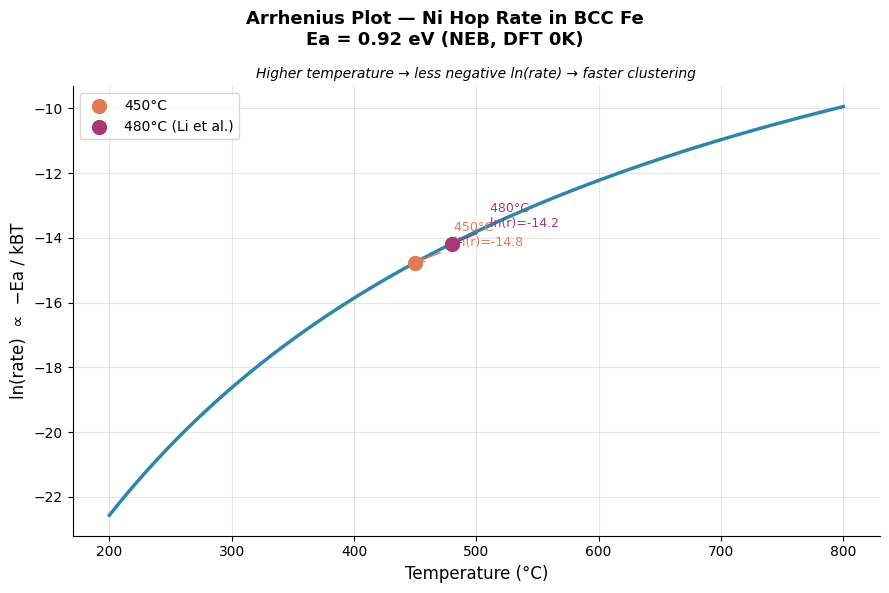

In [2]:
# python3 << 'EOF'
import math
import matplotlib.pyplot as plt
import numpy as np

Ea = 0.920  # eV
kB = 8.617e-5  # eV/K

temps_C = np.linspace(200, 800, 500)
temps_K = temps_C + 273.15
ln_rate = -Ea / (kB * temps_K)

fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle("Arrhenius Plot — Ni Hop Rate in BCC Fe\nEa = 0.92 eV (NEB, DFT 0K)",
             fontsize=13, fontweight='bold')

ax.plot(temps_C, ln_rate, color='#2E86AB', linewidth=2.5)

for T, c, label in [(450, '#E07B54', '450°C'), (480, '#A23B72', '480°C (Li et al.)')]:
    T_K = T + 273.15
    y = -Ea / (kB * T_K)
    ax.scatter([T], [y], color=c, s=100, zorder=5, label=label)
    ax.annotate(f"  {T}°C\n  ln(r)={y:.1f}",
                xy=(T, y), xytext=(T + 25, y + 0.5),
                fontsize=9, color=c,
                arrowprops=dict(arrowstyle='->', color=c))

ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("ln(rate)  ∝  −Ea / kBT", fontsize=12)
ax.set_title("Higher temperature → less negative ln(rate) → faster clustering", 
             fontsize=10, style='italic')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("arrhenius_temp_axis.png", dpi=180, bbox_inches='tight')
print("Saved: arrhenius_temp_axis.png")
# EOF

Saved: barrier_vs_kBT.png


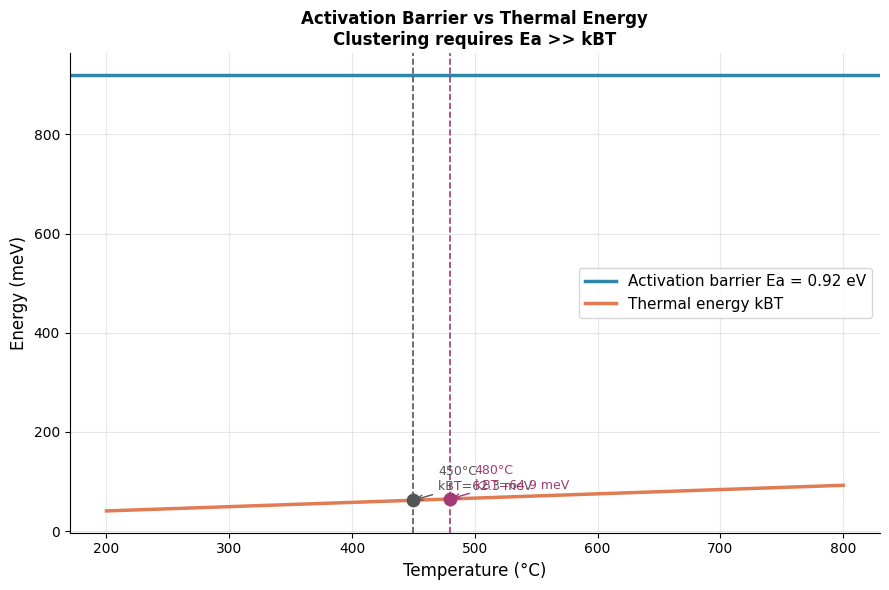

In [3]:
# python3 << 'EOF'
import numpy as np
import matplotlib.pyplot as plt

Ea = 0.920  # eV — this is constant, the answer to his question
kB = 8.617e-5

temps_C = np.linspace(200, 800, 500)
temps_K = temps_C + 273.15
kBT = kB * temps_K * 1000  # meV

fig, ax = plt.subplots(figsize=(9, 6))

# Ea is a flat horizontal line — it doesn't change with temperature
ax.axhline(Ea * 1000, color='#2E86AB', linewidth=2.5, label='Activation barrier Ea = 0.92 eV')

# kBT rises with temperature
ax.plot(temps_C, kBT, color='#E07B54', linewidth=2.5, label='Thermal energy kBT')

# Mark 450 and 480
for T, c in [(450, '#555'), (480, '#A23B72')]:
    T_K = T + 273.15
    kbt_val = kB * T_K * 1000
    ax.axvline(T, color=c, linestyle='--', linewidth=1.2)
    ax.scatter([T], [kbt_val], color=c, s=80, zorder=5)
    ax.annotate(f"{T}°C\nkBT={kbt_val:.1f} meV",
                xy=(T, kbt_val),
                xytext=(T + 20, kbt_val + 20),
                fontsize=9, color=c,
                arrowprops=dict(arrowstyle='->', color=c))

ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Energy (meV)", fontsize=12)
ax.set_title("Activation Barrier vs Thermal Energy\nClustering requires Ea >> kBT",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("barrier_vs_kBT.png", dpi=180, bbox_inches='tight')
print("Saved: barrier_vs_kBT.png")
# EOF